In [1]:
%load_ext autoreload
%autoreload 2

# pi-metaboqc Interactive Pipeline Tutorial

This notebook provides a step-by-step interactive guide to the `pi-metaboqc` metabolomics data quality control pipeline. 

By executing each cell sequentially, you can inspect the intermediate data structures and quality assessment (QA) reports generated at each stage of the workflow.

## Environment Setup


In [2]:
# ====================================================================
# # Environment Setup and Parameter Loading
# ====================================================================
import os
import pandas as pd
from loguru import logger

import pimqc.io_utils as iu
import pimqc.report_utils as ru
from pimqc.dataset_builder import build_dataset
from pimqc.assessment import MetaboIntAssessor
from pimqc.filtering import MetaboIntFilter
from pimqc.correction import MetaboIntCorrector
from pimqc.imputation import MetaboIntImputer
from pimqc.normalization import MetaboIntNormalizer

logger.info("Environment initialized successfully.")

# Define standard directories
DATA_DIR = os.path.join("..", "src", "pimqc", "data")
OUTPUT_DIR = os.path.join(".", "tutorial_output")
iu._check_dir_exists(dir_path=OUTPUT_DIR, handle="makedirs")

# Load SSOT pipeline parameters
PARAMS_PATH = os.path.join(DATA_DIR, "pipeline_parameters.json")
params = iu._load_json_file(input_file_path=PARAMS_PATH)

# Load raw matrices
meta_df = pd.read_csv(
    os.path.join(DATA_DIR, "project_meta.csv"), header=[0])

int_df = pd.read_csv(
    os.path.join(DATA_DIR, "project_intensity.csv"), index_col=[0], header=[0])

2026-04-24 11:51:46.763 | DEBUG    | pimqc:<module>:56 - Windows subprocess patch applied successfully.
2026-04-24 11:51:46.764 | INFO     | __main__:<module>:17 - Environment initialized successfully.
2026-04-24 11:51:46.764 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output.


## Step 1: Dataset Construction
The pipeline initializes the workflow by transforming fragmented raw peak tables and metadata into a standardized `MetaboInt` object. This phase ensures precise coordinate alignment between sample identifiers and feature intensities, establishing a robust structural foundation for all subsequent computational operations.

In [3]:
# ====================================================================
# Step 1: Dataset Construction
# ====================================================================
logger.info("Step 01: Dataset Construction...")
step1_dir = os.path.join(OUTPUT_DIR, "01_Raw_Data")

raw_data = build_dataset(
    meta_info=meta_df,
    int_df=int_df,
    pipeline_params=params,
    mode=params.get("MetaboInt", {}).get("mode", "POS"),
    batch=params.get("MetaboInt", {}).get("batch", "Batch"),
    sample_type=params.get("MetaboInt", {}).get("sample_type", "Sample Type"),
    bio_group=params.get("MetaboInt", {}).get("bio_group", "Bio Group"),
    sample_name=params.get("MetaboInt", {}).get("sample_name", "Sample Name"),
    inject_order=params.get("MetaboInt", {}).get(
        "inject_order", "Inject Order"),
    output_dir=step1_dir
)

is_multi_batch_flag = raw_data.attrs["is_multi_batch"]

2026-04-24 11:51:46.846 | INFO     | __main__:<module>:4 - Step 01: Dataset Construction...
2026-04-24 11:51:46.853 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\01_Raw_Data.
2026-04-24 11:51:46.955 | INFO     | pimqc.dataset_builder:build_dataset:145 - MetaboInt object saved as: .\tutorial_output\01_Raw_Data\Metabolomics_Intensity_Raw_POS.csv
2026-04-24 11:51:46.955 | INFO     | pimqc.dataset_builder:build_dataset:163 - MetaboInt object built, the shape is: (376, 466)
2026-04-24 11:51:46.956 | SUCCESS  | pimqc.io_utils:time_wrap:216 - Execution time of "build_dataset": 00:00:00.108.


## QA-Step 1: Quality Assessment on Raw Data
A comprehensive diagnostic audit of the raw dataset is executed prior to any corrective interventions. This baseline evaluation identifies initial batch offsets, injection-order-dependent signal attenuation, and global missing value distribution topologies.

2026-04-24 11:51:46.980 | INFO     | __main__:<module>:4 - QA-Step 01: Quality Assessment of Raw Data...
2026-04-24 11:51:46.981 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\QA_01_Raw_Data.


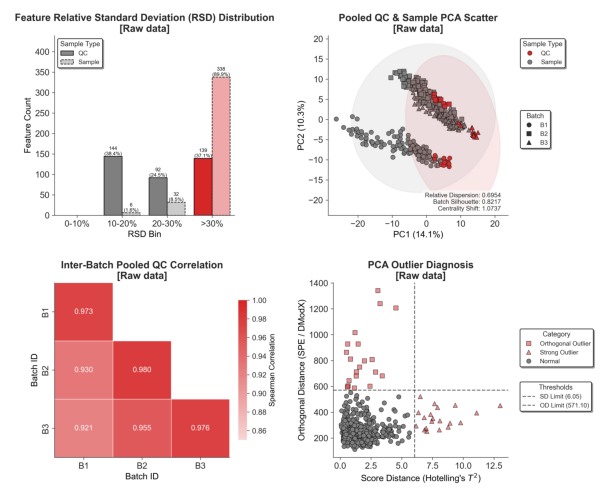

2026-04-24 11:51:54.094 | INFO     | pimqc.assessment:execute_assessment:376 - Assessor summary grid saved as: .\tutorial_output\QA_01_Raw_Data\Assessor_Grid_POS.pdf
2026-04-24 11:51:54.105 | SUCCESS  | pimqc.assessment:execute_assessment:377 - Data quality assessment completed.
2026-04-24 11:51:54.105 | SUCCESS  | pimqc.io_utils:time_wrap:216 - Execution time of "execute_assessment": 00:00:07.123.


In [4]:
# ====================================================================
# QA-Step 1: Quality Assessment (Raw Data)
# ====================================================================
logger.info("QA-Step 01: Quality Assessment of Raw Data...")

qa_step1_dir = os.path.join(OUTPUT_DIR, "QA_01_Raw_Data")
qa_raw_engine = MetaboIntAssessor(data=raw_data, pipeline_params=params)
qa_raw_engine.execute_assessment(output_dir=qa_step1_dir)

## Step 2: High Missing Value Feature Filter
Features exhibiting excessive missingness are systematically removed to preserve statistical power. During this stage, a topology-aware diagnostic is applied to classify missing data into MAR (Missing At Random) and MNAR (Missing Not At Random) populations, which directly guides the algorithmic selection for subsequent imputation.

2026-04-24 11:51:54.140 | INFO     | __main__:<module>:4 - Step 02: High Missing Value Feature Filter...
2026-04-24 11:51:54.152 | INFO     | pimqc.filtering:execute_mv_filtering:261 - High missing value filter (Stage1): Group
2026-04-24 11:51:54.179 | INFO     | pimqc.filtering:classify_missing_types:200 - Classification: 308 MAR, 64 MNAR, Dropping 4 invalid features.
2026-04-24 11:51:54.180 | SUCCESS  | pimqc.io_utils:time_wrap:216 - Execution time of "classify_missing_types": 00:00:00.027.
2026-04-24 11:51:54.185 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\02_MV_Filtered.


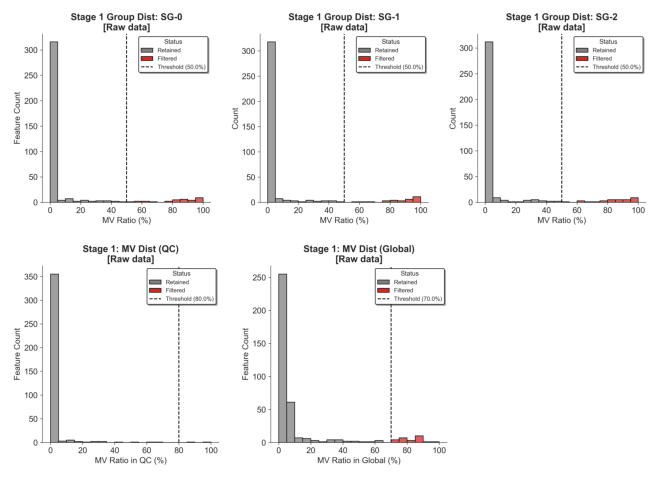

2026-04-24 11:51:59.017 | SUCCESS  | pimqc.filtering:execute_mv_filtering:349 - High-MV features filtering completed.
2026-04-24 11:51:59.018 | SUCCESS  | pimqc.io_utils:time_wrap:216 - Execution time of "execute_mv_filtering": 00:00:04.876.


In [5]:
# ====================================================================
# Step 2: High Missing Value (MV) Feature Filter (Stage 1)
# ====================================================================
logger.info("Step 02: High Missing Value Feature Filter...")

step2_dir = os.path.join(OUTPUT_DIR, "02_MV_Filtered")
fltr_mv_engine = MetaboIntFilter(data=raw_data, pipeline_params=params) 
mv_filter_data = fltr_mv_engine.execute_mv_filtering(output_dir=step2_dir)

## QA-Step 2: Quality Assessment on MV-Filtered Data
The structural integrity of the feature set is verified following the initial missing value filtration. This assessment ensures that global data distributions remain undisturbed and specific sparsity issues have been adequately resolved.

2026-04-24 11:51:59.046 | INFO     | __main__:<module>:4 - QA-Step 02: Quality Assessment of High-MV Filtered Data...
2026-04-24 11:51:59.047 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\QA_02_MV_Filtered.


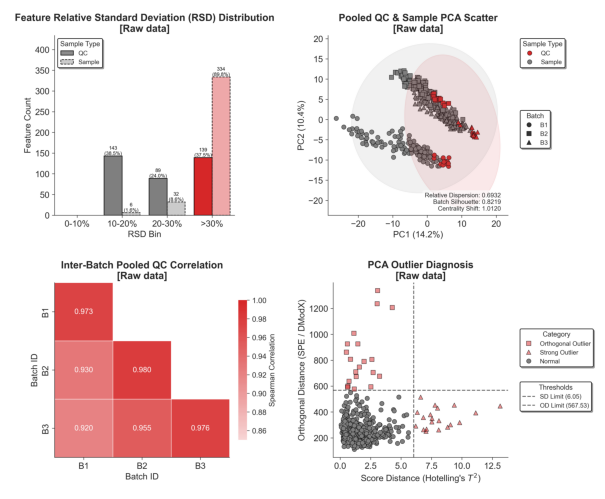

2026-04-24 11:52:05.864 | INFO     | pimqc.assessment:execute_assessment:376 - Assessor summary grid saved as: .\tutorial_output\QA_02_MV_Filtered\Assessor_Grid_POS.pdf
2026-04-24 11:52:05.865 | SUCCESS  | pimqc.assessment:execute_assessment:377 - Data quality assessment completed.
2026-04-24 11:52:05.865 | SUCCESS  | pimqc.io_utils:time_wrap:216 - Execution time of "execute_assessment": 00:00:06.818.


In [6]:
# ====================================================================
# QA-Step 2: Quality Assessment (Post-MV Filtered Data)
# ====================================================================
logger.info("QA-Step 02: Quality Assessment of High-MV Filtered Data...")

qa_step2_dir = os.path.join(OUTPUT_DIR, "QA_02_MV_Filtered")
qa_mv_filter_engine = MetaboIntAssessor(data=mv_filter_data, pipeline_params=params)
qa_mv_filter_engine.execute_assessment(output_dir=qa_step2_dir)

## Step 3 & 4: Signal Drift & Batch Effect Correction
Systemic technical variations, such as temporal sensitivity decay and batch-to-batch intensity shifts, are neutralized. The algorithm stabilizes signal trajectories utilizing QC-anchored regression models (e.g., SVR or LOESS), thereby extracting and preserving true biological variance from instrument-induced noise.

In [7]:
# ====================================================================
# Step 3 & 4: Signal Drift & Batch Effect Correction
# ====================================================================
logger.info("Step 03 & 04: Signal Drift & Batch Effect Correction...")

step3_4_dir = os.path.join(OUTPUT_DIR, "03_04_Corrected_Data")
sc_engine = MetaboIntCorrector(data=mv_filter_data, pipeline_params=params)
intra_sc_data, inter_sc_data = sc_engine.execute_signal_correction(
    output_dir=step3_4_dir)

2026-04-24 11:52:05.897 | INFO     | __main__:<module>:4 - Step 03 & 04: Signal Drift & Batch Effect Correction...
2026-04-24 11:52:05.898 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\03_04_Corrected_Data.
SC [B3]: 100%|███████████████████████████████████████████████████████████████████| 372/372 [Elapsed: 00:00 | ETA: 00:00]
2026-04-24 11:52:19.399 | INFO     | pimqc.correction:execute_signal_correction:322 - Baseline fitting completed
2026-04-24 11:52:19.508 | INFO     | pimqc.correction:execute_signal_correction:334 - Intra-correction completed, saved as : .\tutorial_output\03_04_Corrected_Data\Intra_Batch_Corrected_QC-SVR_POS.csv
2026-04-24 11:52:19.509 | INFO     | pimqc.correction:execute_signal_correction:336 - MetaboInt shape after intra-correction: (372, 466)
2026-04-24 11:52:20.030 | INFO     | pimqc.correction:execute_signal_correction:357 - Inter-correction completed, saved as : .\tutorial_output\03_04_Co

## QA-Step 3: Quality Assessment on Intra-Corrected Data
High-resolution visual audits are conducted to validate the elimination of within-batch drift. Statistical metrics confirm whether individual signal trajectories have been successfully normalized to a stable, horizontal baseline.

2026-04-24 11:52:23.525 | INFO     | __main__:<module>:4 - QA-Step 03: Quality Assessment of Intra-batch Corrected Data...
2026-04-24 11:52:23.526 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\QA_03_Intra_Corrected_Data.


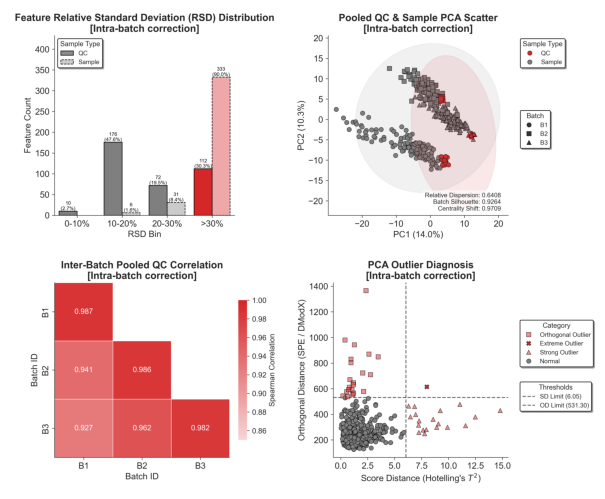

2026-04-24 11:52:30.942 | INFO     | pimqc.assessment:execute_assessment:376 - Assessor summary grid saved as: .\tutorial_output\QA_03_Intra_Corrected_Data\Assessor_Grid_POS.pdf
2026-04-24 11:52:30.943 | SUCCESS  | pimqc.assessment:execute_assessment:377 - Data quality assessment completed.
2026-04-24 11:52:30.944 | SUCCESS  | pimqc.io_utils:time_wrap:216 - Execution time of "execute_assessment": 00:00:07.417.


In [8]:
# ====================================================================
# QA-Step 3: QA on Corrected Data (Intra-Batch)
# ====================================================================
logger.info("QA-Step 03: Quality Assessment of Intra-batch Corrected Data...")

qa_step3_dir = os.path.join(OUTPUT_DIR, "QA_03_Intra_Corrected_Data")
qa_intra_engine = MetaboIntAssessor(data=intra_sc_data, pipeline_params=params) 
qa_intra_engine.execute_assessment(output_dir=qa_step3_dir)

## QA-Step 4: Quality Assessment on Inter-Corrected Data
The alignment of intensity scales across multiple independent acquisition batches is analyzed. This step ensures that the dataset is systemically unified and artificial inter-batch discrepancies have been effectively mitigated.

In [ ]:
# ====================================================================
# QA-Step 4: QA on Corrected Data (Inter-Batch)
# ====================================================================
logger.info("QA-Step 04: Quality Assessment of Inter-batch Corrected Data...")

qa_step4_dir = os.path.join(OUTPUT_DIR, "QA_04_Inter_Corrected_Data")
qa_inter_engine = MetaboIntAssessor(data=inter_sc_data, pipeline_params=params)
qa_inter_engine.execute_assessment(output_dir=qa_step4_dir)

2026-04-24 11:52:30.976 | INFO     | __main__:<module>:4 - QA-Step 04: Quality Assessment of Inter-batch Corrected Data...
2026-04-24 11:52:30.978 | WARNING  | pimqc.io_utils:_check_dir_exists:202 - No such directory, creating a new directory:
	.\tutorial_output\QA_04_Inter_Corrected_Data.


## Step 5: Low-Quality Feature Filter
The feature matrix is further refined based on technical reproducibility and biological relevance. Features heavily contaminated by analytical blanks or those exhibiting poor precision (high RSD) across QC replicates are permanently discarded, yielding a high-fidelity analytical subset.

In [ ]:
# ====================================================================
# Step 5: Low Quality Feature Filter (Stage 2: Blank/QC & RSD)
# ====================================================================
logger.info("Step 05: Low-Quality Feature Filter...")

step5_dir = os.path.join(OUTPUT_DIR, "05_Quality_Filtered")
fltr_low_quality_engine = MetaboIntFilter(data=inter_sc_data, pipeline_params=params)
low_quality_filter_data = fltr_low_quality_engine.execute_quality_filtering(output_dir=step5_dir)

## QA-Step 5: Quality Assessment on Quality-Filtered Data
A pre-imputation health check is performed on the refined dataset. This evaluation confirms that the surviving features represent high-fidelity biological signals, ensuring the matrix is optimally prepared for missing value reconstruction

In [ ]:
# ====================================================================
# QA-Step 5: Quality Assessment (Post-quality Filtered Data)
# ====================================================================
logger.info("QA-Step 05: Quality Assessment of Quality-filtered Data...")

qa_step5_dir = os.path.join(OUTPUT_DIR, "QA_05_Quality_Filtered")

qa_low_quality_filter_engine = MetaboIntAssessor(
    data=low_quality_filter_data, pipeline_params=params)
qa_low_quality_filter_engine.execute_assessment(output_dir=qa_step5_dir)

## Step 6: Missing Value Imputation
An autonomous multi-algorithm benchmarking simulation is executed to address remaining data gaps. The optimal imputation algorithm is programmatically selected based on its proven ability to reconstruct established MNAR/MAR distributions while minimizing bias in the original variance structure.

In [ ]:
# ====================================================================
# Step 6: Missing Value Imputation
# ====================================================================
logger.info("Step 06: Missing Value Imputation...")

step6_dir = os.path.join(OUTPUT_DIR, "06_Imputation")
imp_engine = MetaboIntImputer(data=low_quality_filter_data, pipeline_params=params)
imputed_data = imp_engine.execute_imputation(output_dir=step6_dir)

## QA-Step 6: Quality Assessment on Imputed Data
The statistical fidelity of the imputed values is rigorously evaluated. This step ensures that synthetic data points do not introduce artificial clustering or distort natural biological correlations, with a specific focus on the stability of low-abundance signals

In [ ]:
# ====================================================================
# QA-Step 6: Quality Assessment (Post-Imputation)
# ====================================================================
logger.info("QA-Step 06: Quality Assessment of Imputated Data...")

qa_step6_dir = os.path.join(OUTPUT_DIR, "QA_06_Imputed_Data")
qa_imp_engine = MetaboIntAssessor(data=imputed_data, pipeline_params=params)
qa_imp_engine.execute_assessment(output_dir=qa_step6_dir)

## Step 7 & 8: Sample-wise and Feature-wise Data Normalization
The dataset undergoes final quantitative refinement. Sample-wise (column) normalization is applied to compensate for variations in injection volumes or extraction efficiencies, followed by feature-wise (row) scaling to stabilize variance across differing intensity magnitudes.

In [ ]:
# ====================================================================
# Step 7 & 8: Data Normalization (Sample-wise & Feature-wise)
# ====================================================================
logger.info("Step 07 & 08: Sample-wise and Feature-wise Data Normalization...")

step7_8_dir = os.path.join(OUTPUT_DIR, "07_08_Normalized_Data")
norm_engine = MetaboIntNormalizer(imputed_data, pipeline_params=params)
sample_norm_data, feature_norm_data = norm_engine.execute_normalization(
    output_dir=step7_8_dir) 

## QA-Step 7: Quality Assessment on Sample-wise Normalized Data
The efficacy of the sample-wise normalization is validated. This assessment confirms that global intensity levels across individual samples are properly aligned, effectively removing systematic concentration or injection biases.

In [ ]:
# ====================================================================
# QA-Step 7: QA on Sample-wise Normalized Data
# ====================================================================
logger.info("QA-Step 07: Quality Assessment of Column-wise Normalized Data...")

qa_step7_dir = os.path.join(OUTPUT_DIR, "QA_07_Sample_Norm_Data")
qa_sample_engine = MetaboIntAssessor(data=sample_norm_data, pipeline_params=params)
qa_sample_engine.execute_assessment(output_dir=qa_step7_dir)

## QA-Step 8: Quality Assessment on Feature-wise Normalized Data
A terminal quality audit confirms the dataset's readiness for downstream biological discovery. This phase visually and statistically documents the fully corrected, imputed, and normalized state of the metabolomics study.

In [ ]:
# ====================================================================
# QA-Step 8: QA on Feature-wise Normalized Data (Final Assessment)
# ====================================================================
logger.info("QA-Step 08: Quality Assessment of Feature-wise Normalized Data...")

qa_step8_dir = os.path.join(OUTPUT_DIR, "QA_08_Feature_Norm_Data")
qa_feature_engine = MetaboIntAssessor(data=feature_norm_data, pipeline_params=params)
qa_feature_engine.execute_assessment(output_dir=qa_step8_dir)

## Step 9: Step-Sequential Narrative Report
The workflow concludes by synthesizing all extracted metadata and visual assets. Diagnostic grids are compiled, and critical decision-making metrics are extracted to autonomously generate a comprehensive, human-readable Markdown audit report.

In [ ]:
# ====================================================================
# Step 9: Step-Sequential Narrative Report
# ====================================================================
logger.info("Final: Compiling Sequential Audit Report...")
REPORT_DIR = "09_Report_Markdown"

# # 1. Process Visual Assets
# visual_rep = ru.VisualAssetReporter(
#     base_dir=OUTPUT_DIR
# )
# visual_rep.compile_assessor_report(
#     report_folder=REPORT_DIR, is_multi_batch=is_multi_batch_flag)

# 2. Extract Metadata & Render Markdown (Sequential Mapping)
# 2.1 Define the consolidated object pool using sub-step keys
pipeline_metrics_objs = {
    "raw_dataset": raw_data.dataset_metrics,
    "high_mv_feature_filtering": mv_filter_data.mv_filtering_metrics,
    "intra_signal_correction": intra_sc_data.correction_metrics,
    "inter_signal_correction": inter_sc_data.correction_metrics,
    "low_quality_feature_filtering":
        low_quality_filter_data.quality_filtering_metrics,
    "missing_value_imputation": imputed_data.imputation_metrics,
    "normalization": feature_norm_data.normalization_metrics
}

qa_metrics_objs = {
    "raw_dataset": qa_raw_engine.assessment_metrics,
    "high_mv_feature_filtering": qa_mv_filter_engine.assessment_metrics,
    "intra_signal_correction": qa_intra_engine.assessment_metrics,
    "inter_signal_correction": qa_inter_engine.assessment_metrics,
    "low_quality_feature_filtering":
        qa_low_quality_filter_engine.assessment_metrics,
    "missing_value_imputation": qa_imp_engine.assessment_metrics,
    "sample_wise_normalization": qa_sample_engine.assessment_metrics,
    "feature_wise_normalization": qa_feature_engine.assessment_metrics
}


# 2.2 Initialize reporter and generate ONE markdown file
# stats_rep = ru.NarrativeStatsReporter(base_dir=OUTPUT_DIR)
# stats_rep.generate_markdown(
#     obj_dict=pipeline_metrics_objs, 
#     obj_dict=qa_metrics_objs, 
#     report_folder="09_Report_Markdown"
# )
    
# logger.success("PI-METABOQC PIPELINE COMPLETED SUCCESSFULLY.")

In [ ]:
# raw_data.dataset_metrics
# mv_filter.mv_filtering_metrics
# intra_sc_data.correction_metrics
# inter_sc_data.correction_metrics
# quality_filter.quality_filtering_metrics
# imputed_data.imputation_metrics
# feature_norm_data.normalization_metrics

In [ ]:
# qa_raw_engine.assessment_metrics
# qa_mv_filter_engine.assessment_metrics
# qa_intra_engine.assessment_metrics
# qa_inter_engine.assessment_metrics
# qa_quality_filter_engine.assessment_metrics
# qa_imp_engine.assessment_metrics
# qa_sample_engine.assessment_metrics
# qa_feature_engine.assessment_metrics